In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the data

In [4]:
from google.colab import files

print("Upload your 3 CSV files:")
uploaded = files.upload()

Upload your 3 CSV files:


Saving AccidentsBig.csv to AccidentsBig.csv
Saving CasualtiesBig.csv to CasualtiesBig.csv
Saving VehiclesBig.csv to VehiclesBig.csv


In [5]:
data_accidents = pd.read_csv('AccidentsBig.csv', low_memory=False)
data_casualties = pd.read_csv('CasualtiesBig.csv', low_memory=False)
data_vehicles = pd.read_csv('VehiclesBig.csv', low_memory=False)

In [6]:
print("Accidents shape:", data_accidents.shape)
print("Casualties shape:", data_casualties.shape)
print("Vehicles shape:", data_vehicles.shape)

Accidents shape: (1048575, 30)
Casualties shape: (59998, 15)
Vehicles shape: (1048575, 22)


Check Data with .describe()

In [7]:
data_accidents.describe()

,Accident_Index,longitude,latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,...,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident
count,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,...,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000
mean,29999.500000,78.098483,22.083749,4.304360,2.855512,1.832028,1.320761,4.124637,71.151072,3.982183,...,330.956232,0.006184,0.856262,1.902713,1.386846,1.298377,0.089236,0.048035,1.185356,1.198573
std,17320.075062,5.949539,5.655470,4.569113,0.380983,0.692804,0.762099,1.923690,63.827188,1.360867,...,1185.561831,0.102529,1.896282,1.486875,1.267965,0.541992,0.644405,0.481461,0.389618,0.439712
min,1.000000,69.015103,8.864429,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,-1.000000,-1.000000,-1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,1.000000,-1.000000
25%,15000.250000,73.895816,18.555476,1.000000,3.000000,1.000000,1.000000,3.000000,18.000000,3.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
50%,29999.500000,77.050768,22.732800,4.000000,3.000000,2.000000,1.000000,4.000000,73.000000,3.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,44998.750000,78.544677,27.091517,6.000000,3.000000,2.000000,1.000000,6.000000,107.000000,5.000000,...,0.000000,0.000000,0.000000,4.000000,1.000000,2.000000,0.000000,0.000000,1.000000,1.000000
max,59998.000000,94.231931,31.068800,48.000000,3.000000,18.000000,23.000000,7.000000,570.000000,6.000000,...,9711.000000,2.000000,8.000000,7.000000,9.000000,5.000000,7.000000,7.000000,3.000000,3.000000


Find Negative Values Using .describe()

In [8]:
# Get min values from describe()
min_values = data_accidents.describe().loc['min']
print("Columns with negative min values:")
print(min_values[min_values < 0])

Columns with negative min values:
Junction_Detail                               -1.0
Junction_Control                              -1.0
2nd_Road_Class                                -1.0
2nd_Road_Number                               -1.0
Pedestrian_Crossing-Human_Control             -1.0
Pedestrian_Crossing-Physical_Facilities       -1.0
Road_Surface_Conditions                       -1.0
Special_Conditions_at_Site                    -1.0
Carriageway_Hazards                           -1.0
Did_Police_Officer_Attend_Scene_of_Accident   -1.0
Name: min, dtype: float64


Count Negative Values in Each Column

In [9]:
print("Count of negative values:")
for col in data_accidents.select_dtypes(include=[np.number]).columns:
    count = (data_accidents[col] < 0).sum()
    if count > 0:
        print(f"{col}: {count}")

Count of negative values:
Junction_Detail: 5
Junction_Control: 19745
2nd_Road_Class: 19808
2nd_Road_Number: 148
Pedestrian_Crossing-Human_Control: 13
Pedestrian_Crossing-Physical_Facilities: 16
Road_Surface_Conditions: 50
Special_Conditions_at_Site: 8
Carriageway_Hazards: 10
Did_Police_Officer_Attend_Scene_of_Accident: 162


Aggregate Casualties and Vehicles

In [10]:
# Aggregate casualties by Accident_Index
casualties_agg = data_casualties.groupby('Accident_Index').mean(numeric_only=True).reset_index()
print("Casualties aggregated:", casualties_agg.shape)

Casualties aggregated: (59998, 15)


In [11]:
# Aggregate vehicles by Accident_Index
vehicles_agg = data_vehicles.groupby('Accident_Index').mean(numeric_only=True).reset_index()
print("Vehicles aggregated:", vehicles_agg.shape)

Vehicles aggregated: (59999, 22)


Merge 3 Datasets on Accident_Index

In [12]:
# Merge accidents with casualties
data = pd.merge(data_accidents, casualties_agg, on='Accident_Index', how='left')
print("After merging casualties:", data.shape)

After merging casualties: (1048575, 44)


In [13]:
# Merge with vehicles
data = pd.merge(data, vehicles_agg, on='Accident_Index', how='left')
print("After merging vehicles:", data.shape)

After merging vehicles: (1048575, 65)


In [15]:
data.head()

,Accident_Index,longitude,latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Time,Local_Authority_(District),...,Was_Vehicle_Left_Hand_Drive?,Journey_Purpose_of_Driver,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type
0,1.0,78.610393,14.724026,1.0,2.0,1.0,1.0,3.0,17:42,12.0,...,1.0,15.0,2.0,74.0,10.0,-1.0,-1.0,-1.0,7.0,1.0
1,2.0,78.534042,14.762353,1.0,3.0,1.0,1.0,4.0,17:36,12.0,...,1.0,1.0,1.0,42.0,7.0,8268.0,2.0,3.0,-1.0,-1.0
2,3.0,78.470877,14.745606,1.0,3.0,2.0,1.0,5.0,00:15,12.0,...,1.0,1.0,1.0,35.0,6.0,8300.0,2.0,5.0,2.0,1.0
3,4.0,78.557994,14.667128,1.0,3.0,1.0,1.0,6.0,10:35,12.0,...,1.0,15.0,1.0,62.0,9.0,1762.0,1.0,6.0,1.0,1.0
4,5.0,78.576431,14.703443,1.0,3.0,1.0,1.0,2.0,21:13,12.0,...,1.0,15.0,2.0,49.0,8.0,1769.0,1.0,4.0,2.0,1.0


Drop Irrelevant Columns





In [16]:
# Extract useful time features BEFORE dropping
if 'Time' in data.columns:
    data['Hour'] = pd.to_datetime(data['Time'], format='%H:%M', errors='coerce').dt.hour
    # Create day/night indicator
    data['Is_Night'] = ((data['Hour'] >= 19) | (data['Hour'] < 6)).astype(int)

# Columns to drop
cols_to_drop = ['Accident_Index', 'longitude', 'latitude', 'Location_Easting_OSGR',
                'Location_Northing_OSGR', 'LSOA_of_Accident_Location', 'Date', 'Time',  # Drop Time AFTER extracting Hour
                'Local_Authority_(Highway)', 'Local_Authority_(District)']

cols_to_drop = [col for col in cols_to_drop if col in data.columns]
data = data.drop(columns=cols_to_drop)

Remove Rows with Missing Severity

In [17]:
print("Before dropping missing severity column:", data.shape)
data = data.dropna(subset=['Accident_Severity'])
print("After dropping missing severity column:", data.shape)

Before dropping missing severity column: (1048575, 59)
After dropping missing severity column: (59998, 59)


Check Data Balance

In [18]:
print("Severity distribution:")
print(data['Accident_Severity'].value_counts().sort_index())

Severity distribution:
Accident_Severity
1.0      646
2.0     7377
3.0    51975
Name: count, dtype: int64


In [19]:
# Count and percentage
severity_counts = data['Accident_Severity'].value_counts().sort_index()
total = len(data)

print("\nClass distribution:")
for severity, count in severity_counts.items():
    pct = (count / total) * 100
    print(f"Class {severity}: {count} ({pct:.2f}%)")

print(f"\nTotal: {total}")


Class distribution:
Class 1.0: 646 (1.08%)
Class 2.0: 7377 (12.30%)
Class 3.0: 51975 (86.63%)

Total: 59998


In [20]:
# Calculate imbalance ratio
max_count = severity_counts.max()
min_count = severity_counts.min()
ratio = max_count / min_count
print(f"\nImbalance ratio: {ratio:.2f}:1")


Imbalance ratio: 80.46:1


Plot Imbalance Graph

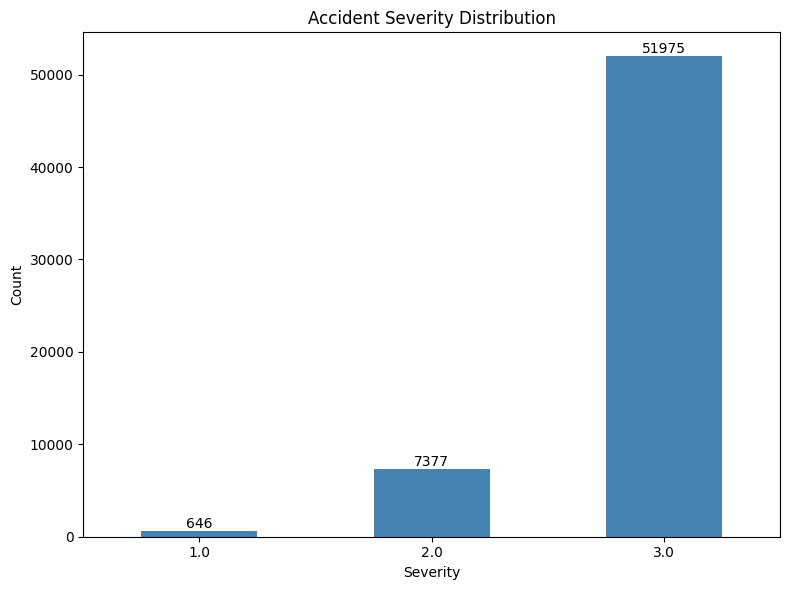

In [21]:
plt.figure(figsize=(8, 6))
severity_counts.plot(kind='bar', color='steelblue')
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Add count labels on bars
for i, v in enumerate(severity_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Check Negative Values After Merge

In [23]:
print("Negative values in merged data:")
for col in data.select_dtypes(include=[np.number]).columns:
    count = (data[col] < 0).sum()
    if count > 0:
        print(f"{col}: {count}")

Negative values in merged data:
Junction_Detail: 5
Junction_Control: 19745
2nd_Road_Class: 19808
2nd_Road_Number: 148
Pedestrian_Crossing-Human_Control: 13
Pedestrian_Crossing-Physical_Facilities: 16
Road_Surface_Conditions: 50
Special_Conditions_at_Site: 8
Carriageway_Hazards: 10
Did_Police_Officer_Attend_Scene_of_Accident: 162
Sex_of_Casualty: 3
Age_of_Casualty: 2686
Age_Band_of_Casualty: 2686
Pedestrian_Road_Maintenance_Worker: 59998
Casualty_Home_Area_Type: 13825
Vehicle_Type: 16
Towing_and_Articulation: 1
Vehicle_Manoeuvre: 14
Vehicle_Location-Restricted_Lane: 16
Junction_Location: 79
Skidding_and_Overturning: 8
Hit_Object_in_Carriageway: 7
Vehicle_Leaving_Carriageway: 8
Hit_Object_off_Carriageway: 7
1st_Point_of_Impact: 63
Was_Vehicle_Left_Hand_Drive?: 2832
Journey_Purpose_of_Driver: 2997
Age_of_Driver: 11482
Age_Band_of_Driver: 11482
Engine_Capacity_(CC): 20730
Propulsion_Code: 20061
Age_of_Vehicle: 22143
Driver_IMD_Decile: 16930
Driver_Home_Area_Type: 16725


Replace -1 with NaN



In [24]:
# Replace -1 values with NaN (missing indicator)
data = data.replace(-1, np.nan)
print("Replaced -1 with NaN")

Replaced -1 with NaN


In [25]:
# Check missing values
print("\nMissing values per column:")
missing = data.isnull().sum()
print(missing[missing > 0])


Missing values per column:
Junction_Detail                                    5
Junction_Control                               19745
2nd_Road_Class                                 19808
2nd_Road_Number                                  148
Pedestrian_Crossing-Human_Control                 13
Pedestrian_Crossing-Physical_Facilities           16
Road_Surface_Conditions                           50
Special_Conditions_at_Site                         8
Carriageway_Hazards                               10
Did_Police_Officer_Attend_Scene_of_Accident      162
Sex_of_Casualty                                    3
Age_of_Casualty                                 2686
Age_Band_of_Casualty                            2686
Pedestrian_Road_Maintenance_Worker             59998
Casualty_Home_Area_Type                        13825
Vehicle_Type                                      16
Towing_and_Articulation                            1
Vehicle_Manoeuvre                                 14
Vehicle_Location-R

Fill Missing Values

In [28]:
# Fill numeric with median
for col in data.select_dtypes(include=[np.number]).columns:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())
# Fill categorical/text with mode or 'Unknown'
for col in data.select_dtypes(include=['object']).columns:
    if data[col].isnull().sum() > 0:
        mode_val = data[col].mode()
        if len(mode_val) > 0:
            data[col] = data[col].fillna(mode_val[0])
        else:
            data[col] = data[col].fillna('Unknown')
print("Missing values filled")
print("Remaining missing:", data.isnull().sum().sum())

Missing values filled
Remaining missing: 59998


In [29]:
# Check which columns still have missing values
print("\nColumns with missing values:")
missing_info = data.isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

for col, count in missing_info.items():
    print(f"{col}: {count} missing ({count/len(data)*100:.1f}%)")


Columns with missing values:
Pedestrian_Road_Maintenance_Worker: 59998 missing (100.0%)


In [30]:
# Drop column with all missing values
data = data.drop(columns=['Pedestrian_Road_Maintenance_Worker'])

print("Dropped Pedestrian_Road_Maintenance_Worker column")
print("Remaining missing:", data.isnull().sum().sum())

Dropped Pedestrian_Road_Maintenance_Worker column
Remaining missing: 0


Final Dataset


In [31]:
print("Final dataset shape:", data.shape)
print("\nColumns:", len(data.columns))
print("Rows:", len(data))

Final dataset shape: (59998, 58)

Columns: 58
Rows: 59998


In [32]:
data.head()

,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,...,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Hour,Is_Night
0,1.0,2.0,1.0,1.0,3.0,3.0,3218.0,6.0,30.0,0.0,...,2.0,74.0,10.0,1598.0,1.0,6.0,7.0,1.0,17.0,0
1,1.0,3.0,1.0,1.0,4.0,4.0,450.0,3.0,30.0,6.0,...,1.0,42.0,7.0,8268.0,2.0,3.0,4.0,1.0,17.0,0
2,1.0,3.0,2.0,1.0,5.0,5.0,0.0,6.0,30.0,0.0,...,1.0,35.0,6.0,8300.0,2.0,5.0,2.0,1.0,0.0,1
3,1.0,3.0,1.0,1.0,6.0,3.0,3220.0,6.0,30.0,0.0,...,1.0,62.0,9.0,1762.0,1.0,6.0,1.0,1.0,10.0,0
4,1.0,3.0,1.0,1.0,2.0,6.0,0.0,6.0,30.0,0.0,...,2.0,49.0,8.0,1769.0,1.0,4.0,2.0,1.0,21.0,1


In [33]:
data.describe()

,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,...,Sex_of_Driver,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Hour,Is_Night
count,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,...,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000
mean,4.304360,2.855512,1.832028,1.320761,4.124637,3.982183,901.988450,5.233858,35.055002,2.722191,...,1.348345,37.254258,6.679239,1818.440215,1.178206,6.345012,4.508634,1.091586,13.810310,0.245642
std,4.569113,0.380983,0.692804,0.762099,1.923690,1.360867,1755.837897,1.578772,11.456121,2.586412,...,0.582561,12.799984,1.437881,1386.829223,0.428936,3.463130,2.259064,0.383062,5.214364,0.430471
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,10.000000,0.000000,...,1.000000,1.000000,1.000000,12.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,1.000000,1.000000,3.000000,3.000000,0.000000,6.000000,30.000000,0.000000,...,1.000000,29.000000,6.000000,1398.000000,1.000000,5.000000,3.000000,1.000000,10.000000,0.000000
50%,4.000000,3.000000,2.000000,1.000000,4.000000,3.000000,110.000000,6.000000,30.000000,3.000000,...,1.000000,36.000000,7.000000,1598.000000,1.000000,6.000000,4.000000,1.000000,15.000000,0.000000
75%,6.000000,3.000000,2.000000,1.000000,6.000000,5.000000,583.000000,6.000000,30.000000,3.000000,...,2.000000,43.000000,7.000000,1796.000000,1.000000,7.000000,6.000000,1.000000,18.000000,0.000000
max,48.000000,3.000000,18.000000,23.000000,7.000000,6.000000,9999.000000,9.000000,70.000000,9.000000,...,3.000000,97.000000,11.000000,24980.000000,8.000000,48.000000,10.000000,3.000000,23.000000,1.000000


Final Data Summary

In [34]:
print("DATA SUMMARY")
print("="*50)
print(f"Total rows: {len(data)}")
print(f"Total columns: {len(data.columns)}")
print(f"\nSeverity distribution:")
for severity, count in data['Accident_Severity'].value_counts().sort_index().items():
    pct = (count / len(data)) * 100
    print(f"  Class {severity}: {count} ({pct:.2f}%)")
print(f"\nMissing values: {data.isnull().sum().sum()}")
print(f"Negative values: {(data.select_dtypes(include=[np.number]) < 0).sum().sum()}")

DATA SUMMARY
Total rows: 59998
Total columns: 58

Severity distribution:
  Class 1.0: 646 (1.08%)
  Class 2.0: 7377 (12.30%)
  Class 3.0: 51975 (86.63%)

Missing values: 0
Negative values: 0


Check Imbalace (Apply SMOTE for Oversampling the imbalanced data(since data is heavily imbalanced))

In [35]:
print("BEFORE SMOTE:")
print("="*50)

severity_counts = data['Accident_Severity'].value_counts().sort_index()
total = len(data)

for severity, count in severity_counts.items():
    pct = (count / total) * 100
    print(f"Class {severity}: {count:>6,} ({pct:>5.2f}%)")

print(f"\nTotal: {total:,}")

# Calculate imbalance
max_count = severity_counts.max()
min_count = severity_counts.min()
ratio = max_count / min_count
print(f"Imbalance ratio: {ratio:.2f}:1")

BEFORE SMOTE:
Class 1.0:    646 ( 1.08%)
Class 2.0:  7,377 (12.30%)
Class 3.0: 51,975 (86.63%)

Total: 59,998
Imbalance ratio: 80.46:1


In [36]:
# Separate X (features) and y (target)
X = data.drop(columns=['Accident_Severity'])
y = data['Accident_Severity']

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (59998, 57)
Target (y): (59998,)


In [42]:
# Install if needed (run once)
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nSMOTE applied successfully!")

Applying SMOTE...

SMOTE applied successfully!


In [38]:
print("\nAFTER SMOTE:")
print("="*50)

severity_counts_after = pd.Series(y_balanced).value_counts().sort_index()
total_after = len(y_balanced)

for severity, count in severity_counts_after.items():
    pct = (count / total_after) * 100
    print(f"Class {severity}: {count:>6,} ({pct:>5.2f}%)")

print(f"\nTotal: {total_after:,}")
print(f"\nRows increased: {total:,} → {total_after:,}")


AFTER SMOTE:
Class 1.0: 51,975 (33.33%)
Class 2.0: 51,975 (33.33%)
Class 3.0: 51,975 (33.33%)

Total: 155,925

Rows increased: 59,998 → 155,925


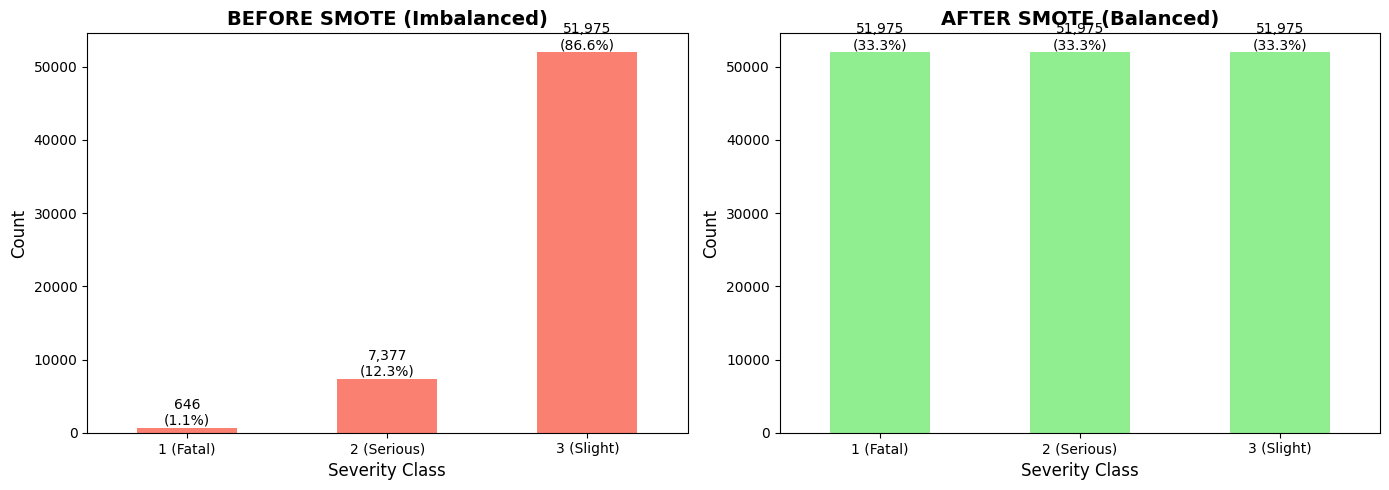

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
severity_counts.plot(kind='bar', ax=ax1, color='salmon')
ax1.set_title('BEFORE SMOTE (Imbalanced)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Severity Class', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_xticklabels(['1 (Fatal)', '2 (Serious)', '3 (Slight)'], rotation=0)

for i, v in enumerate(severity_counts):
    pct = (v / total) * 100
    ax1.text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

# After SMOTE
severity_counts_after.plot(kind='bar', ax=ax2, color='lightgreen')
ax2.set_title('AFTER SMOTE (Balanced)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Severity Class', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_xticklabels(['1 (Fatal)', '2 (Serious)', '3 (Slight)'], rotation=0)

for i, v in enumerate(severity_counts_after):
    pct = (v / total_after) * 100
    ax2.text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [40]:
# Combine balanced features and target
data_balanced = X_balanced.copy()
data_balanced['Accident_Severity'] = y_balanced

print("Final balanced dataset shape:", data_balanced.shape)
print("\nReady for model training!")

Final balanced dataset shape: (155925, 58)

Ready for model training!


In [41]:
# View final dataset
data_balanced.head()

,Police_Force,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Detail,Junction_Control,...,Age_of_Driver,Age_Band_of_Driver,Engine_Capacity_(CC),Propulsion_Code,Age_of_Vehicle,Driver_IMD_Decile,Driver_Home_Area_Type,Hour,Is_Night,Accident_Severity
0,1.0,1.0,1.0,3.0,3.0,3218.0,6.0,30.0,0.0,4.0,...,74.0,10.0,1598.0,1.0,6.0,7.0,1.0,17.0,0,2.0
1,1.0,1.0,1.0,4.0,4.0,450.0,3.0,30.0,6.0,2.0,...,42.0,7.0,8268.0,2.0,3.0,4.0,1.0,17.0,0,3.0
2,1.0,2.0,1.0,5.0,5.0,0.0,6.0,30.0,0.0,4.0,...,35.0,6.0,8300.0,2.0,5.0,2.0,1.0,0.0,1,3.0
3,1.0,1.0,1.0,6.0,3.0,3220.0,6.0,30.0,0.0,4.0,...,62.0,9.0,1762.0,1.0,6.0,1.0,1.0,10.0,0,3.0
4,1.0,1.0,1.0,2.0,6.0,0.0,6.0,30.0,0.0,4.0,...,49.0,8.0,1769.0,1.0,4.0,2.0,1.0,21.0,1,3.0
